# M0 - Baseline regression lineaire (5 variables)

Objectif:
- entrainer une baseline lineaire sur `train.csv`
- utiliser uniquement les 5 variables retenues dans l'analyse
- comparer plusieurs strategies de preprocessing avec la meme CV
- selectionner la meilleure configuration puis generer une soumission Kaggle

Variables retenues:
`['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

# Pour le VIF (installé si nécessaire)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    VIF_AVAILABLE = True
except ImportError:
    print("statsmodels non disponible - analyse VIF skip")
    VIF_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
# Chargement des donnees
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
print(f"sample_submission shape: {sample_submission.shape}")

# Feature engineering: AgeAtSale = annee de vente - annee de construction
for df in [train_df, test_df]:
    df["AgeAtSale"] = df["YrSold"] - df["YearBuilt"]

features = ["OverallQual", "GrLivArea", "TotalBsmtSF", "AgeAtSale", "Neighborhood"]
target = "SalePrice"

print("Features baseline:", features)


train shape: (1460, 81)
test shape: (1459, 80)
sample_submission shape: (1459, 2)
Features baseline: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']


## Détection des outliers

Analyse des outliers sur les variables de surface pour un baseline robuste.

Détection des outliers (méthode IQR):

GrLivArea:
  Nombre d'outliers: 31 (2.12%)
  Bornes: [158.62, 2747.62]

TotalBsmtSF:
  Nombre d'outliers: 61 (4.18%)
  Bornes: [42.00, 2052.00]


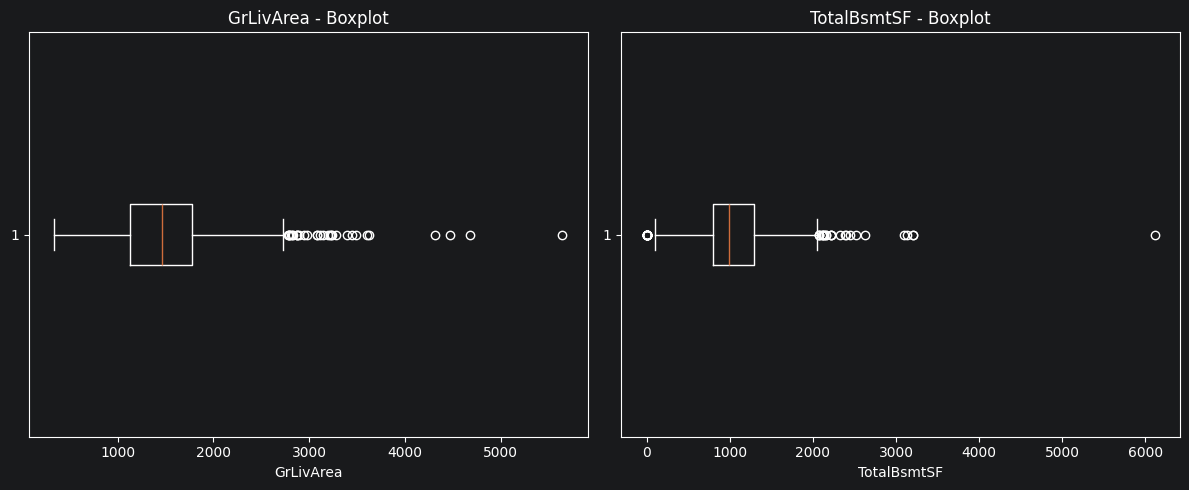


Variables winsorisées créées pour comparaison future.


In [3]:
# Détection des outliers sur les variables de surface
surface_vars = ['GrLivArea', 'TotalBsmtSF']

def detect_outliers_iqr(df, variables, threshold=1.5):
    """Détection des outliers avec la méthode IQR"""
    outliers_info = {}

    for var in variables:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

        outliers_info[var] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_indices': outliers.index.tolist(),
        }

    return outliers_info

# Détection des outliers
outliers_info = detect_outliers_iqr(train_df, surface_vars)

print("Détection des outliers (méthode IQR):")
for var, info in outliers_info.items():
    print(f"\n{var}:")
    print(f"  Nombre d'outliers: {info['count']} ({info['percentage']:.2f}%)")
    print(f"  Bornes: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")

# Visualisation des outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(surface_vars):
    axes[i].boxplot(train_df[var].dropna(), vert=False)
    axes[i].set_title(f'{var} - Boxplot')
    axes[i].set_xlabel(var)

plt.tight_layout()
plt.show()

# Option: Winsorisation (remplacer les outliers par les bornes)
def winsorize_series(series, lower_bound, upper_bound):
    return series.clip(lower_bound, upper_bound)

# Création de versions winsorisées pour comparaison éventuelle
train_df_winsorized = train_df.copy()
for var in surface_vars:
    info = outliers_info[var]
    train_df_winsorized[f'{var}_winsorized'] = winsorize_series(
        train_df[var], info['lower_bound'], info['upper_bound']
    )

print("\nVariables winsorisées créées pour comparaison future.")

## Analyse de la multicolinéarité (VIF)

Calcul du Variance Inflation Factor pour vérifier la multicolinéarité.

In [4]:
# Analyse VIF (si statsmodels disponible)
if VIF_AVAILABLE:
    def calculate_vif(df, features):
        """Calcul du VIF pour un ensemble de variables"""
        # Préparation des données (imputation simple pour VIF)
        df_vif = df[features].copy()

        # Imputation basique pour le calcul VIF
        for col in df_vif.columns:
            if df_vif[col].dtype == 'object':
                continue
            else:
                df_vif[col] = df_vif[col].fillna(df_vif[col].median())

        # Sélection des variables numériques uniquement
        numeric_features = df_vif.select_dtypes(include=[np.number]).columns.tolist()
        df_numeric = df_vif[numeric_features]

        # Ajout de constante pour VIF
        X_with_const = add_constant(df_numeric)

        vif_data = []
        for i, feature in enumerate(numeric_features):
            vif_value = variance_inflation_factor(X_with_const.values, i + 1)
            vif_data.append({
                'feature': feature,
                'vif': vif_value
            })

        return pd.DataFrame(vif_data).sort_values('vif', ascending=False)

    # VIF pour les 5 variables de base
    numeric_features_5 = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale']
    vif_5 = calculate_vif(train_df, numeric_features_5)

    print("VIF pour les 5 variables numériques de base:")
    print(vif_5)

    # VIF avec la 6ème variable
    numeric_features_6 = numeric_features_5 + ['GarageCars']
    vif_6 = calculate_vif(train_df, numeric_features_6)

    print("\nVIF avec GarageCars ajouté:")
    print(vif_6)

    print("\nInterprétation des VIF:")
    print("- VIF < 5: Multicolinéarité faible à modérée")
    print("- VIF 5-10: Multicolinéarité modérée à élevée")
    print("- VIF > 10: Multicolinéarité élevée (problématique)")
else:
    print("statsmodels non disponible - analyse VIF skip")

VIF pour les 5 variables numériques de base:
       feature       vif
0  OverallQual  2.432911
1    GrLivArea  1.706635
3    AgeAtSale  1.603720
2  TotalBsmtSF  1.509510

VIF avec GarageCars ajouté:
       feature       vif
0  OverallQual  2.538228
4   GarageCars  1.845036
3    AgeAtSale  1.801269
1    GrLivArea  1.800687
2  TotalBsmtSF  1.519968

Interprétation des VIF:
- VIF < 5: Multicolinéarité faible à modérée
- VIF 5-10: Multicolinéarité modérée à élevée
- VIF > 10: Multicolinéarité élevée (problématique)


## Vérification des valeurs manquantes

Avant d'aller plus loin, vérifions les valeurs manquantes pour nos 5 variables de base.

In [5]:
# Verification des valeurs manquantes pour les 5 variables
missing_train = train_df[features].isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df[features].isna().mean().mul(100).sort_values(ascending=False)

print("Missing % (train):")
print(missing_train)
print("\nMissing % (test):")
print(missing_test)


Missing % (train):
OverallQual     0.0
GrLivArea       0.0
TotalBsmtSF     0.0
AgeAtSale       0.0
Neighborhood    0.0
dtype: float64

Missing % (test):
TotalBsmtSF     0.06854
OverallQual     0.00000
GrLivArea       0.00000
AgeAtSale       0.00000
Neighborhood    0.00000
dtype: float64


In [6]:
# X / y
X_train = train_df[features].copy()
X_test = test_df[features].copy()

y_train = train_df[target].copy()
y_train_log = np.log1p(y_train)


## Protocole de comparaison

On garde le meme modele (`LinearRegression`) et les memes 5 variables.
Seul le preprocessing varie entre les experiences.


In [7]:
# CV fixe pour comparer toutes les experiences a armes egales

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

rmse_scorer = make_scorer(rmse, greater_is_better=False)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Groupes de colonnes (inchanges)
num_plain_median_features = ["OverallQual", "AgeAtSale"]
num_surface_median_features = ["GrLivArea"]
num_surface_zero_features = ["TotalBsmtSF"]
cat_features = ["Neighborhood"]


def make_numeric_pipeline(imputer_strategy="median", fill_value=None, log_transform=False, scale=False):
    steps = []
    if imputer_strategy == "constant":
        steps.append(("imputer", SimpleImputer(strategy="constant", fill_value=fill_value)))
    else:
        steps.append(("imputer", SimpleImputer(strategy=imputer_strategy)))

    if log_transform:
        steps.append(("log1p", FunctionTransformer(np.log1p, validate=False)))

    if scale:
        steps.append(("scaler", StandardScaler()))

    return Pipeline(steps=steps)


def build_preprocessor(config):
    use_scale = config["scale_numeric"]
    drop_first = config["drop_first"]
    log_surfaces = config["log_surfaces"]
    neighborhood_missing = config["neighborhood_missing"]

    cat_imputer = SimpleImputer(strategy="constant", fill_value="Missing")
    if neighborhood_missing == "most_frequent":
        cat_imputer = SimpleImputer(strategy="most_frequent")

    cat_encoder = OneHotEncoder(
        handle_unknown="ignore",
        drop="first" if drop_first else None,
    )

    transformers = [
        (
            "num_plain",
            make_numeric_pipeline(imputer_strategy="median", log_transform=False, scale=use_scale),
            num_plain_median_features,
        ),
        (
            "num_surface_median",
            make_numeric_pipeline(imputer_strategy="median", log_transform=log_surfaces, scale=use_scale),
            num_surface_median_features,
        ),
        (
            "num_surface_zero",
            make_numeric_pipeline(imputer_strategy="constant", fill_value=0, log_transform=log_surfaces, scale=use_scale),
            num_surface_zero_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", cat_imputer),
                    ("onehot", cat_encoder),
                ]
            ),
            cat_features,
        ),
    ]

    return ColumnTransformer(transformers=transformers)


def build_pipeline(config):
    preprocessor = build_preprocessor(config)
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression()),
        ]
    )



## Experiences de preprocessing

Total: 10 configurations testees pour explorer systematiquement l'impact du preprocessing.

Dimensions explorees:
- **scale_numeric** (False / True): StandardScaler sur variables numeriques
- **drop_first** (False / True): OneHotEncoder avec drop='first' pour eviter colinearite
- **log_surfaces** (False / True): log1p sur GrLivArea et TotalBsmtSF
- **neighborhood_missing** ("missing" / "most_frequent"): Strategie pour valeurs manquantes categoriques

### Descriptions des 10 configs:
- E0: baseline sans transformations
- E1: baseline + drop_first
- E2: baseline + scale
- E3: baseline + log surfaces
- E4: E3 + scale (log+scale combination)
- E5: baseline + neighborhood imputees au mode
- E6: E3 + drop_first (log surfaces avec drop_first)
- E7: E4 + drop_first (log surfaces + scale + drop_first)
- E8: E2 + neighborhood mode (scale avec neighborhood mode)
- E9: E3 + neighborhood mode (log surfaces avec neighborhood mode)


In [8]:
experiment_configs = [
    {
        "name": "E0_baseline",
        "scale_numeric": False,
        "drop_first": False,
        "log_surfaces": False,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E1_drop_first",
        "scale_numeric": False,
        "drop_first": True,
        "log_surfaces": False,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E2_scale_numeric",
        "scale_numeric": True,
        "drop_first": False,
        "log_surfaces": False,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E3_log_surfaces",
        "scale_numeric": False,
        "drop_first": False,
        "log_surfaces": True,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E4_log_surfaces_scale",
        "scale_numeric": True,
        "drop_first": False,
        "log_surfaces": True,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E5_neighborhood_mode",
        "scale_numeric": False,
        "drop_first": False,
        "log_surfaces": False,
        "neighborhood_missing": "most_frequent",
    },
    {
        "name": "E6_log_surfaces_drop_first",
        "scale_numeric": False,
        "drop_first": True,
        "log_surfaces": True,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E7_log_surfaces_scale_drop_first",
        "scale_numeric": True,
        "drop_first": True,
        "log_surfaces": True,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E8_neighborhood_mode_scale",
        "scale_numeric": True,
        "drop_first": False,
        "log_surfaces": False,
        "neighborhood_missing": "most_frequent",
    },
    {
        "name": "E9_neighborhood_mode_log",
        "scale_numeric": False,
        "drop_first": False,
        "log_surfaces": True,
        "neighborhood_missing": "most_frequent",
    },
]

results = []
for cfg in experiment_configs:
    pipeline = build_pipeline(cfg)

    fold_rmse_log = []
    fold_mae_price = []
    fold_rmsle_price = []
    fold_overpred_pct = []
    fold_r2_scores = []
    fold_mape_scores = []

    for train_idx, val_idx in cv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr_log = y_train_log.iloc[train_idx]
        y_val_log = y_train_log.iloc[val_idx]
        y_val_price = y_train.iloc[val_idx]

        model_fold = clone(pipeline)
        model_fold.fit(X_tr, y_tr_log)

        pred_val_log = model_fold.predict(X_val)
        pred_val_price = np.expm1(pred_val_log)
        pred_val_price = np.clip(pred_val_price, a_min=0, a_max=None)

        residual_price = pred_val_price - y_val_price.to_numpy()
        overpred_rate = (residual_price > 0).mean() * 100

        fold_rmse_log.append(rmse(y_val_log, pred_val_log))
        fold_mae_price.append(mean_absolute_error(y_val_price, pred_val_price))
        fold_rmsle_price.append(rmsle(y_val_price, pred_val_price))
        fold_overpred_pct.append(overpred_rate)

        # Nouvelles métriques enrichies
        fold_r2_scores.append(r2_score(y_val_price, pred_val_price))
        fold_mape_scores.append(mean_absolute_percentage_error(y_val_price, pred_val_price))

    results.append(
        {
            "config": cfg["name"],
            "cv_rmse_log_mean": np.mean(fold_rmse_log),
            "cv_rmse_log_std": np.std(fold_rmse_log),
            "cv_mae_price_mean": np.mean(fold_mae_price),
            "cv_mae_price_std": np.std(fold_mae_price),
            "cv_rmsle_price_mean": np.mean(fold_rmsle_price),
            "cv_rmsle_price_std": np.std(fold_rmsle_price),
            "cv_overpred_pct_mean": np.mean(fold_overpred_pct),
            "cv_overpred_pct_std": np.std(fold_overpred_pct),
            "cv_r2_mean": np.mean(fold_r2_scores),
            "cv_r2_std": np.std(fold_r2_scores),
            "cv_mape_mean": np.mean(fold_mape_scores),
            "cv_mape_std": np.std(fold_mape_scores),
            "fold_rmse_log": np.round(fold_rmse_log, 5).tolist(),
        }
    )

results_df = pd.DataFrame(results)

## Decision finale: classement global pondere

Strategie de ponderation (contexte banque):
1. **60% poids** : minimiser la sur-prediction (risque critique pour le cretit)
2. **40% poids** : minimiser l'erreur absolue en euros (MAE)
3. **20% poids** : minimiser l'erreur Kaggle (RMSE log)

Le classement global combine ces trois objectifs via un rang pondere.


In [9]:
# Contexte banque: priorite au metier (MAE + sur-prediction basse)
w_kaggle = 0.2
w_mae_business = 0.4
w_overpred_business = 0.6

decision_df = results_df.copy()
decision_df["rank_kaggle"] = decision_df["cv_rmse_log_mean"].rank(method="min", ascending=True)
decision_df["rank_business_mae"] = decision_df["cv_mae_price_mean"].rank(method="min", ascending=True)
decision_df["rank_business_overpred"] = decision_df["cv_overpred_pct_mean"].rank(method="min", ascending=True)

decision_df["rank_global_weighted"] = (
    w_kaggle * decision_df["rank_kaggle"]
    + w_mae_business * decision_df["rank_business_mae"]
    + w_overpred_business * decision_df["rank_business_overpred"]
)

decision_df = decision_df.sort_values(
    ["rank_global_weighted", "cv_mae_price_mean", "cv_overpred_pct_mean", "cv_rmse_log_mean"]
).reset_index(drop=True)

print("Tableau de decision global (toutes les configurations):")
print("\nLecture des colonnes:")
print("- config: nom de l'experience")
print("- cv_rmse_log_mean: RMSE en echelle log (metrique Kaggle, plus bas=mieux)")
print("- cv_mae_price_mean: erreur absolue en euros (plus bas=mieux)")
print("- cv_overpred_pct_mean: % de sur-predictions (plus bas=mieux, risque critique)")
print("- rank_kaggle / rank_business_mae / rank_business_overpred: rangs individuels (1=meilleur)")
print("- rank_global_weighted: rang pondere final (1=meilleur global globa)")
print()

display(
    decision_df[
        [
            "config",
            "cv_rmse_log_mean",
            "cv_mae_price_mean",
            "cv_overpred_pct_mean",
            "rank_kaggle",
            "rank_business_mae",
            "rank_business_overpred",
            "rank_global_weighted",
        ]
    ]
)

best_global_config = decision_df.iloc[0]["config"]
print(f"\n✓ Configuration gagnante (global weighted): {best_global_config}")

best_config = next(cfg for cfg in experiment_configs if cfg["name"] == best_global_config)
print("\nParametres detailles:")
for k, v in best_config.items():
    if k != "name":
        print(f"  {k}: {v}")


Tableau de decision global (toutes les configurations):

Lecture des colonnes:
- config: nom de l'experience
- cv_rmse_log_mean: RMSE en echelle log (metrique Kaggle, plus bas=mieux)
- cv_mae_price_mean: erreur absolue en euros (plus bas=mieux)
- cv_overpred_pct_mean: % de sur-predictions (plus bas=mieux, risque critique)
- rank_kaggle / rank_business_mae / rank_business_overpred: rangs individuels (1=meilleur)
- rank_global_weighted: rang pondere final (1=meilleur global globa)



,config,cv_rmse_log_mean,cv_mae_price_mean,cv_overpred_pct_mean,rank_kaggle,rank_business_mae,rank_business_overpred,rank_global_weighted
0,E7_log_surfaces_scale_drop_first,0.162856,21164.406002,47.808219,2.0,1.0,6.0,4.4
1,E4_log_surfaces_scale,0.162856,21164.407117,47.808219,3.0,2.0,6.0,5.0
2,E6_log_surfaces_drop_first,0.162856,21164.566132,47.808219,1.0,3.0,6.0,5.0
3,E2_scale_numeric,0.171051,21336.176215,46.712329,6.0,8.0,1.0,5.0
4,E8_neighborhood_mode_scale,0.171051,21336.176215,46.712329,6.0,8.0,1.0,5.0
5,E3_log_surfaces,0.162857,21164.628315,47.808219,4.0,4.0,6.0,6.0
6,E9_neighborhood_mode_log,0.162857,21164.628315,47.808219,4.0,4.0,6.0,6.0
7,E0_baseline,0.171096,21324.848718,46.849315,8.0,6.0,4.0,6.4
8,E5_neighborhood_mode,0.171096,21324.848718,46.849315,8.0,6.0,4.0,6.4
9,E1_drop_first,0.171193,21360.267389,46.712329,10.0,10.0,1.0,6.6



✓ Configuration gagnante (global weighted): E7_log_surfaces_scale_drop_first

Parametres detailles:
  scale_numeric: True
  drop_first: True
  log_surfaces: True
  neighborhood_missing: missing


## Test d'une 6ème variable prometteuse

Basé sur l'analyse exploratoire, nous testons `GarageCars` comme variable additionnelle.

In [10]:
# Test rapide avec GarageCars ajouté
features_6 = features + ['GarageCars']
X_train_6 = train_df[features_6].copy()
X_test_6 = test_df[features_6].copy()

print("Features avec GarageCars:", features_6)

# Test rapide sur une configuration fixe (celle gagnante)
config_test = best_config.copy()
config_test['name'] = 'Test_6_vars'

pipeline_5 = build_pipeline(best_config)
pipeline_6 = build_pipeline(config_test)

# CV rapide pour comparer 5 vs 6 variables
cv_scores_5 = cross_val_score(pipeline_5, X_train, y_train_log, cv=cv, scoring='neg_mean_absolute_error')
cv_scores_6 = cross_val_score(pipeline_6, X_train_6, y_train_log, cv=cv, scoring='neg_mean_absolute_error')

mae_5 = -cv_scores_5.mean()
mae_6 = -cv_scores_6.mean()

print(f"MAE CV avec 5 variables: {mae_5:.2f} (+/- {cv_scores_5.std():.2f})")
print(f"MAE CV avec 6 variables: {mae_6:.2f} (+/- {cv_scores_6.std():.2f})")
print(f"Différence: {mae_6 - mae_5:.2f} (négatif = amélioration)")

if mae_6 < mae_5:
    print("✅ GarageCars améliore les performances")
else:
    print("❌ GarageCars n'améliore pas (ou détériore) les performances")

# Vérification multicolinéarité avec GarageCars
if VIF_AVAILABLE:
    vif_garage = calculate_vif(train_df, features_6[:-1] + ['GarageCars'])  # features_6 sans Neighborhood
    print("\nVIF avec GarageCars:")
    print(vif_garage)


Features avec GarageCars: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood', 'GarageCars']
MAE CV avec 5 variables: 0.12 (+/- 0.01)
MAE CV avec 6 variables: 0.12 (+/- 0.01)
Différence: 0.00 (négatif = amélioration)
❌ GarageCars n'améliore pas (ou détériore) les performances

VIF avec GarageCars:
       feature       vif
0  OverallQual  2.538228
4   GarageCars  1.845036
3    AgeAtSale  1.801269
1    GrLivArea  1.800687
2  TotalBsmtSF  1.519968


## Learning curves

Analyse des courbes d'apprentissage pour diagnostiquer over/underfitting.

Learning curves pour la configuration gagnante:


/home/nilo/anaconda3/envs/group_projet_data_science/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/nilo/anaconda3/envs/group_projet_data_science/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/nilo/anaconda3/envs/group_projet_data_science/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/nilo/anaconda3/envs/group_projet_data_science/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categ

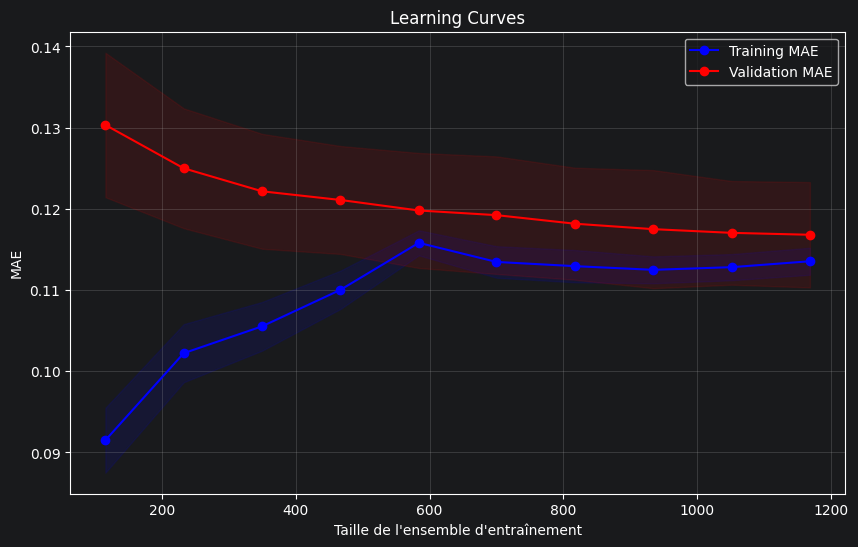

Gap final (Validation - Training): 0.00
✅ Gap faible: Bonne généralisation


In [11]:
# Learning curves
def plot_learning_curves(pipeline, X, y, train_sizes=None, cv=None):
    """Génération et affichage des learning curves"""
    if train_sizes is None:
        train_sizes = np.linspace(0.1, 1.0, 10)

    # Calcul des learning curves
    train_sizes_abs, train_scores, val_scores = learning_curve(
        pipeline, X, y, train_sizes=train_sizes, cv=cv,
        scoring='neg_mean_absolute_error', n_jobs=-1
    )

    # Conversion en MAE positif
    train_scores_mean = -train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = -val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)

    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Training MAE')
    plt.fill_between(train_sizes_abs,
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std,
                     alpha=0.1, color='blue')

    plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='red', label='Validation MAE')
    plt.fill_between(train_sizes_abs,
                     val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std,
                     alpha=0.1, color='red')

    plt.xlabel('Taille de l\'ensemble d\'entraînement')
    plt.ylabel('MAE')
    plt.title('Learning Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Analyse du gap
    final_gap = val_scores_mean[-1] - train_scores_mean[-1]
    print(f"Gap final (Validation - Training): {final_gap:.2f}")

    if final_gap > 5000:
        print("⚠️  Gap élevé: Possible overfitting")
    elif final_gap < 1000:
        print("✅ Gap faible: Bonne généralisation")
    else:
        print("📊 Gap modéré: Équilibre acceptable")

# Learning curves pour la meilleure configuration
print("Learning curves pour la configuration gagnante:")
plot_learning_curves(build_pipeline(best_config), X_train, y_train_log, cv=cv)

## Analyse des résidus

Diagnostic complet des résidus pour valider les hypothèses du modèle linéaire.

Analyse complète des résidus:
  Moyenne des résidus: 3145.79
  Écart-type des résidus: 34566.54
  Skewness: 2.998
  Kurtosis: 18.058
  Test de normalité (Shapiro-Wilk): p-value = 0.0000


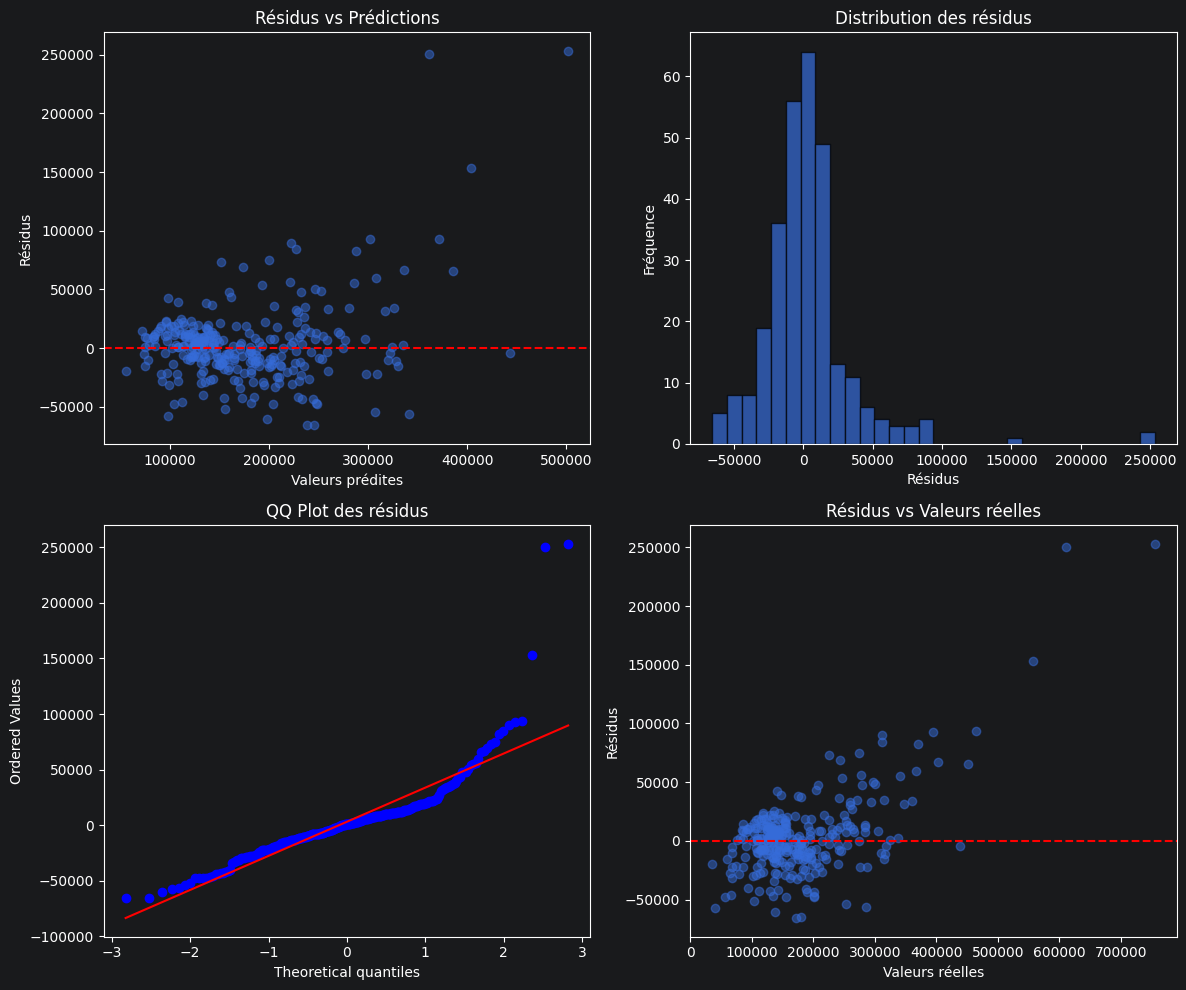

In [12]:
# Analyse détaillée des résidus
def analyze_residuals_comprehensive(y_true, y_pred):
    """Analyse complète des résidus"""
    residuals = y_true - y_pred

    return {
        'residuals': residuals,
        'mean_residual': np.mean(residuals),
        'std_residual': np.std(residuals),
        'skewness': stats.skew(residuals),
        'kurtosis': stats.kurtosis(residuals),
        'normality_test': stats.shapiro(residuals[:5000]) if len(residuals) > 5000 else stats.shapiro(residuals)
    }

# Calcul sur un fold pour illustration
pipeline_test = build_pipeline(best_config)
train_idx, val_idx = next(cv.split(X_train))
X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_tr_log, y_val_log = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
y_val_price = y_train.iloc[val_idx]

pipeline_test.fit(X_tr, y_tr_log)
pred_val_log = pipeline_test.predict(X_val)
pred_val_price = np.expm1(pred_val_log)

# Analyse des résidus
residuals_analysis = analyze_residuals_comprehensive(y_val_price, pred_val_price)

print("Analyse complète des résidus:")
print(f"  Moyenne des résidus: {residuals_analysis['mean_residual']:.2f}")
print(f"  Écart-type des résidus: {residuals_analysis['std_residual']:.2f}")
print(f"  Skewness: {residuals_analysis['skewness']:.3f}")
print(f"  Kurtosis: {residuals_analysis['kurtosis']:.3f}")
print(f"  Test de normalité (Shapiro-Wilk): p-value = {residuals_analysis['normality_test'].pvalue:.4f}")

# Visualisation complète des résidus
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Résidus vs prédictions
axes[0, 0].scatter(pred_val_price, residuals_analysis['residuals'], alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valeurs prédites')
axes[0, 0].set_ylabel('Résidus')
axes[0, 0].set_title('Résidus vs Prédictions')

# Histogramme des résidus
axes[0, 1].hist(residuals_analysis['residuals'], bins=30, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Résidus')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution des résidus')

# QQ plot des résidus
stats.probplot(residuals_analysis['residuals'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ Plot des résidus')

# Résidus vs valeurs réelles
axes[1, 1].scatter(y_val_price, residuals_analysis['residuals'], alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Valeurs réelles')
axes[1, 1].set_ylabel('Résidus')
axes[1, 1].set_title('Résidus vs Valeurs réelles')

plt.tight_layout()
plt.show()

## Diagnostic visuel du modele gagnant (train, out-of-fold)

On trace `valeur reelle` (x) vs `valeur predite` (y) pour la configuration gagnante,
avec des predictions out-of-fold (meme CV) pour eviter la fuite de donnees.


OOF MAE (prix reel): 21164.41
OOF RMSE (prix reel): 34262.39
OOF RMSLE (erreur relative): 0.1631


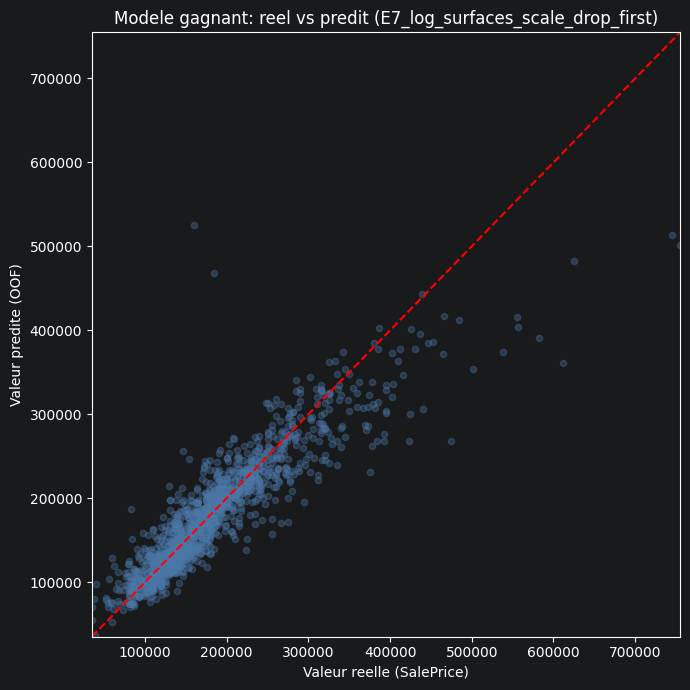

In [13]:
oof_pred_log = np.zeros(len(X_train), dtype=float)

for train_idx, val_idx in cv.split(X_train):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr_log = y_train_log.iloc[train_idx]

    model_fold = clone(build_pipeline(best_config))
    model_fold.fit(X_tr, y_tr_log)
    oof_pred_log[val_idx] = model_fold.predict(X_val)

oof_pred_price = np.expm1(oof_pred_log)
oof_pred_price = np.clip(oof_pred_price, a_min=0, a_max=None)

oof_mae = mean_absolute_error(y_train, oof_pred_price)
oof_rmse = rmse(y_train, oof_pred_price)
oof_rmsle = rmsle(y_train, oof_pred_price)
print(f"OOF MAE (prix reel): {oof_mae:.2f}")
print(f"OOF RMSE (prix reel): {oof_rmse:.2f}")
print(f"OOF RMSLE (erreur relative): {oof_rmsle:.4f}")

min_axis = min(float(y_train.min()), float(oof_pred_price.min()))
max_axis = max(float(y_train.max()), float(oof_pred_price.max()))

plt.figure(figsize=(7, 7))
plt.scatter(y_train, oof_pred_price, alpha=0.35, s=20, color="#4C78A8")
plt.plot([min_axis, max_axis], [min_axis, max_axis], color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Valeur reelle (SalePrice)")
plt.ylabel("Valeur predite (OOF)")
plt.title(f"Modele gagnant: reel vs predit ({best_global_config})")
plt.xlim(min_axis, max_axis)
plt.ylim(min_axis, max_axis)
plt.tight_layout()
plt.show()


# Entrainement final

In [14]:
# Entrainement final avec la meilleure configuration globale
best_pipeline = build_pipeline(best_config)
best_pipeline.fit(X_train, y_train_log)

# Prediction sur test puis retour a l'echelle du prix
test_pred_log = best_pipeline.predict(X_test)
test_pred = np.expm1(test_pred_log)

# Securite numerique: eviter des valeurs negatives dues a l'approximation lineaire
test_pred = np.clip(test_pred, a_min=0, a_max=None)

print("Predictions test - min / max:", float(test_pred.min()), float(test_pred.max()))


Predictions test - min / max: 46902.308383236654 473989.1517428789


In [15]:
# Creation du fichier de soumission Kaggle
submission = sample_submission.copy()
submission["SalePrice"] = test_pred

output_path = BASE_DIR / f"submission_m0_linear_{best_global_config}.csv"
submission.to_csv(output_path, index=False)

print(f"Submission ecrite: {output_path}")
submission.head()


Submission ecrite: submission_m0_linear_E7_log_surfaces_scale_drop_first.csv


,Id,SalePrice
0,1461,118603.210006
1,1462,156676.789916
2,1463,164349.834146
3,1464,179771.174572
4,1465,239982.993656
